In [2]:
# load dot env
from dotenv import load_dotenv
import os
load_dotenv()

False

In [3]:
# import all libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels
import yfinance as yf
import os


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Program Files\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Program Files\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\akash\AppData\Roaming\Python\Python310\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\akash\AppData\Roaming\Python\Python310\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  Fi

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [ ]:
def get_data(ticker):
    # check if ticker.csv is in data folder if it is load the csv and return it
    if os.path.exists(f'data/{ticker}.csv'):
        data = pd.read_csv(f'data/{ticker}.csv')
        # make sure the date column is a datetime object
        data['Datetime'] = pd.to_datetime(data['Datetime'])
        # make it the index
        data.set_index('Datetime', inplace=True)
        # make all other columns numeric
        data = data.apply(pd.to_numeric, errors='coerce')
        return data
    
    # if the csv does not exist download the data from yahoo finance
    ticker_obj = yf.Ticker(ticker)
    data = ticker_obj.history(period='max', interval='90m')
    data.to_csv(f'data/{ticker}.csv')
    return data

In [ ]:
btc = get_data('XRP-USD')
btc.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2024-10-05 21:00:00+00:00,0.529911,0.531159,0.529377,0.530882,380032,0.0,0.0
2024-10-05 22:30:00+00:00,0.530887,0.532300,0.529245,0.529493,732736,0.0,0.0
2024-10-06 00:00:00+00:00,0.529496,0.532177,0.528520,0.532155,592512,0.0,0.0
2024-10-06 01:30:00+00:00,0.532196,0.532662,0.531122,0.531345,603328,0.0,0.0
2024-10-06 03:00:00+00:00,0.531322,0.531570,0.529565,0.530697,7848704,0.0,0.0


In [ ]:
dir(btc.index)

# get last 30 days
btc.index[-1] - pd.DateOffset(days=1)

Timestamp('2024-12-03 21:00:00+0000', tz='UTC')

In [ ]:
# plot open, high, and low
sns.set_style('whitegrid')

plt.figure(figsize=(12, 6))

plt.plot(btc['Open'], label='Open', color='blue')
plt.plot(btc['High'], label='High', color='green')
plt.plot(btc['Low'], label='Low', color='red')

plt.title('XRP-USD')
plt.xlabel('Date')
plt.ylabel('Price')

""" DAYS = 3

plt.xlim(btc.index[-1] - pd.DateOffset(days=DAYS), btc.index[-1]) """

NameError: name 'sns' is not defined

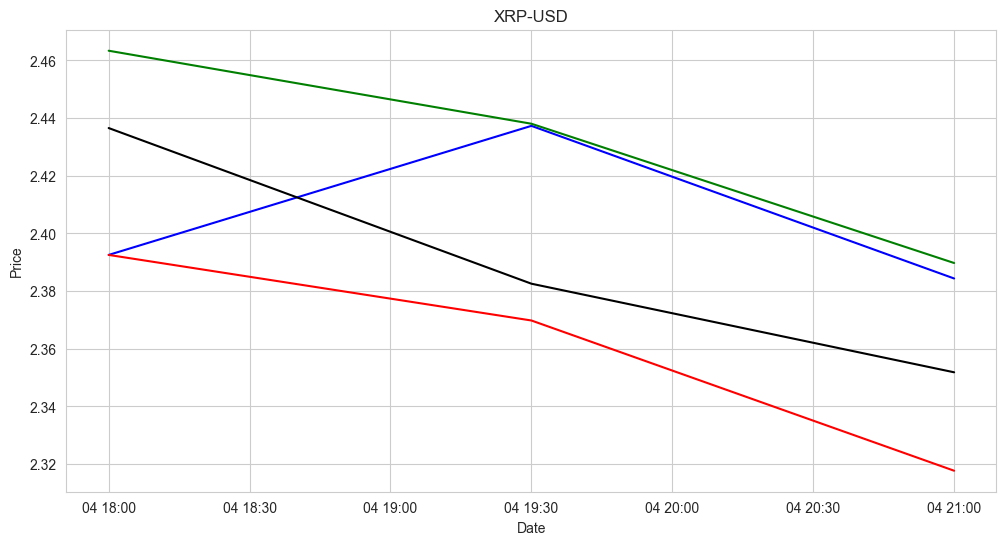

In [ ]:
# make a candlestick stock plot with open, high, low, close
plt.figure(figsize=(12, 6))

plt.plot(btc.index[-DAYS:], btc['Open'][-DAYS:], label='Open', color='blue')
plt.plot(btc.index[-DAYS:], btc['High'][-DAYS:], label='High', color='green')
plt.plot(btc.index[-DAYS:], btc['Low'][-DAYS:], label='Low', color='red')
plt.plot(btc.index[-DAYS:], btc['Close'][-DAYS:], label='Close', color='black')

plt.title('XRP-USD')
plt.xlabel('Date')
plt.ylabel('Price')

plt.show()

In [ ]:
import random

# Initialize Positions DataFrame
positions = pd.DataFrame(columns=["Date Bought", "Price Bought", "Price Sold", "Value Sold", "Time Sold", "Time Held", "Gross Profit"])

cash_balance = 10000  # Starting cash
crypto_balance = 0
positions = pd.DataFrame(columns=[
    "Date Bought", "Price Bought", "Price Sold", "Value Sold", 
    "Gross Profit", "Time Sold", "Time Held", "Type"
])
portfolio_value = []
profits_over_time = []
cash_over_time = []
crypto_over_time = []

In [ ]:
def execute_trades(data, stop_loss_pct=0.05, limit_pct=0.1, coin_orders=10):
    """
    Executes trades on the data, supporting buying/selling multiple coins at once.

    Parameters:
    - data: DataFrame of price data.
    - stop_loss_pct: Stop loss percentage for closing positions.
    - limit_pct: Limit percentage for taking profits.
    - coin_orders: Number of coins to buy or sell in a single transaction.
    """
    global cash_balance, crypto_balance, positions

    for i in range(0, len(data), 6):  # Every 90 minutes
        row = data.iloc[i]
        price = row['Open']
        date = row.name
        action = random.choice(["buy", "nothing", "short"])  # Random action
        # probs = [0.4, 0.4, 0.2]  # Probabilities for buy, nothing, short
        # action = np.random.choice(["buy", "nothing", "short"], p=probs)

        # Check for stop/limit order criteria
        for idx, position in positions[positions["Price Sold"].isna()].iterrows():
            if position["Type"] == "buy":
                stop_price = position["Price Bought"] * (1 - stop_loss_pct)
                limit_price = position["Price Bought"] * (1 + limit_pct)
                if price <= stop_price or price >= limit_price:
                    # Sell to close buy position
                    coins_to_sell = min(coin_orders, crypto_balance)
                    crypto_balance -= coins_to_sell
                    cash_balance += coins_to_sell * price
                    gross_profit = coins_to_sell * (price - position["Price Bought"])
                    positions.loc[idx, "Price Sold"] = price
                    positions.loc[idx, "Value Sold"] = price * coins_to_sell
                    positions.loc[idx, "Gross Profit"] = gross_profit
                    positions.loc[idx, "Time Sold"] = date
                    positions.loc[idx, "Time Held"] = date - position["Date Bought"]

            elif position["Type"] == "short":
                stop_price = position["Price Bought"] * (1 + stop_loss_pct)
                limit_price = position["Price Bought"] * (1 - limit_pct)
                if price >= stop_price or price <= limit_price:
                    # Buy to cover short position
                    coins_to_cover = coin_orders  # All short positions are for `coin_orders`
                    cash_balance -= coins_to_cover * price
                    gross_profit = coins_to_cover * (position["Price Bought"] - price)
                    positions.loc[idx, "Price Sold"] = price
                    positions.loc[idx, "Value Sold"] = price * coins_to_cover
                    positions.loc[idx, "Gross Profit"] = gross_profit
                    positions.loc[idx, "Time Sold"] = date
                    positions.loc[idx, "Time Held"] = date - position["Date Bought"]

        # Perform random action
        if action == "buy" and cash_balance > price * coin_orders:
            # Execute Buy
            crypto_balance += coin_orders
            cash_balance -= price * coin_orders
            positions = pd.concat([positions, pd.DataFrame({
                "Date Bought": [date],
                "Price Bought": [price],
                "Price Sold": [None],
                "Value Sold": [None],
                "Gross Profit": [None],
                "Time Sold": [None],
                "Time Held": [None],
                "Type": ["buy"]
            })], ignore_index=True)

        elif action == "short" and cash_balance > price * coin_orders:
            # Open Short Position
            cash_balance += price * coin_orders  # Borrow and sell immediately
            positions = pd.concat([positions, pd.DataFrame({
                "Date Bought": [date],
                "Price Bought": [price],
                "Price Sold": [None],
                "Value Sold": [None],
                "Gross Profit": [None],
                "Time Sold": [None],
                "Time Held": [None],
                "Type": ["short"]
            })], ignore_index=True)

        # Track portfolio and balances
        total_portfolio_value = cash_balance + (crypto_balance * price)
        portfolio_value.append((date, total_portfolio_value))
        profits_over_time.append((date, positions["Gross Profit"].sum()))
        cash_over_time.append((date, cash_balance))
        crypto_over_time.append((date, crypto_balance))

# Example Execution
execute_trades(btc, coin_orders=500)

C:\Users\akash\AppData\Local\Temp\ipykernel_5852\2431622209.py:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  positions = pd.concat([positions, pd.DataFrame({


In [ ]:
# Convert tracking lists to DataFrames
portfolio_df = pd.DataFrame(portfolio_value, columns=["Date", "Portfolio Value"])
profits_df = pd.DataFrame(profits_over_time, columns=["Date", "Cumulative Profit"])
cash_df = pd.DataFrame(cash_over_time, columns=["Date", "Cash Balance"])
crypto_df = pd.DataFrame(crypto_over_time, columns=["Date", "Crypto Balance"])

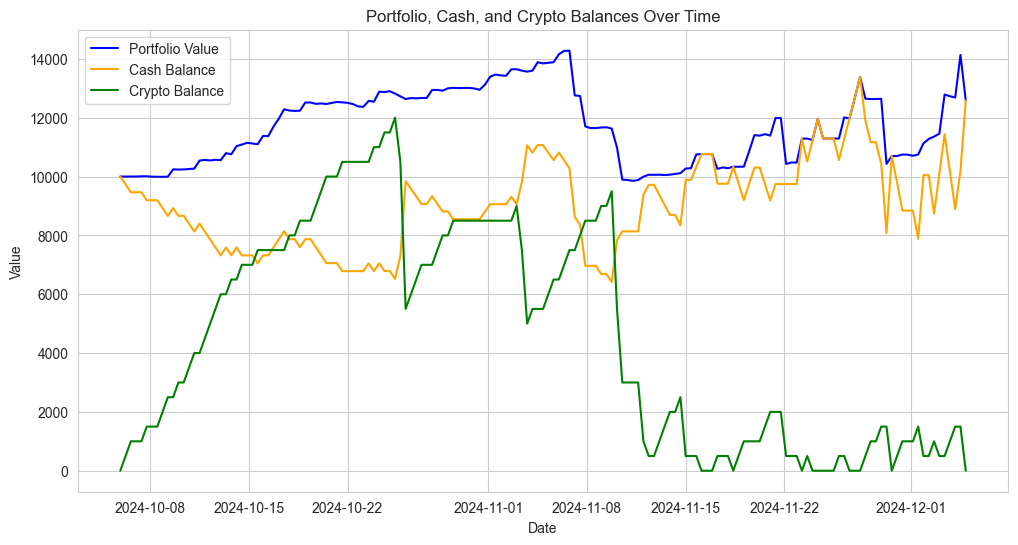

In [ ]:
# Plot Portfolio, Cash, and Crypto Balances Over Time
plt.figure(figsize=(12, 6))

plt.plot(portfolio_df["Date"], portfolio_df["Portfolio Value"], label="Portfolio Value", color="blue")
plt.plot(cash_df["Date"], cash_df["Cash Balance"], label="Cash Balance", color="orange")
plt.plot(crypto_df["Date"], crypto_df["Crypto Balance"], label="Crypto Balance", color="green")

plt.title("Portfolio, Cash, and Crypto Balances Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()


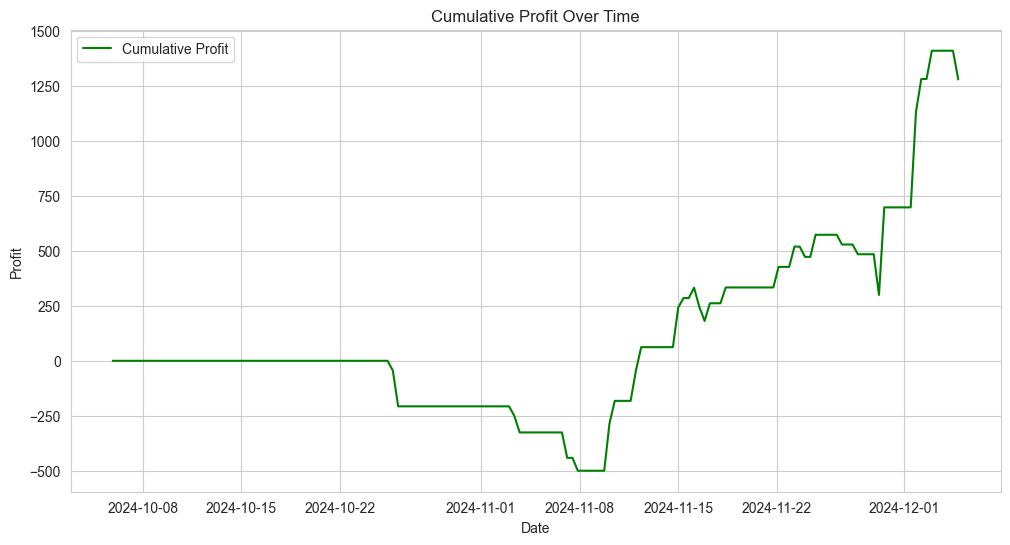

In [ ]:
# Plot Profits Over Time
plt.figure(figsize=(12, 6))
plt.plot(profits_df["Date"], profits_df["Cumulative Profit"], label="Cumulative Profit", color="green")
plt.title("Cumulative Profit Over Time")
plt.xlabel("Date")
plt.ylabel("Profit")
plt.legend()
plt.show()

In [ ]:
# show the rows with the highest gross profit
positions.sort_values('Gross Profit', ascending=True).head(20)

,Date Bought,Price Bought,Price Sold,Value Sold,Gross Profit,Time Sold,Time Held,Type
71,2024-11-19 12:00:00+00:00,1.102314,1.358457,679.228544,-128.071606,2024-11-22 03:00:00+00:00,2 days 15:00:00,short
72,2024-11-19 21:00:00+00:00,1.102335,1.358457,679.228544,-128.061175,2024-11-22 03:00:00+00:00,2 days 06:00:00,short
75,2024-11-21 09:00:00+00:00,1.120880,1.358457,679.228544,-118.788481,2024-11-22 03:00:00+00:00,0 days 18:00:00,short
92,2024-12-02 15:00:00+00:00,2.618856,2.384389,1192.194581,-117.233396,2024-12-04 21:00:00+00:00,2 days 06:00:00,buy
94,2024-12-03 18:00:00+00:00,2.571073,2.384389,1192.194581,-93.341827,2024-12-04 21:00:00+00:00,1 days 03:00:00,buy
65,2024-11-15 18:00:00+00:00,0.866168,1.040339,520.169735,-87.085694,2024-11-16 12:00:00+00:00,0 days 18:00:00,short
95,2024-12-04 03:00:00+00:00,2.529917,2.384389,1192.194581,-72.76392,2024-12-04 21:00:00+00:00,0 days 18:00:00,buy
83,2024-11-27 09:00:00+00:00,1.434554,1.565124,782.561839,-65.284669,2024-11-29 06:00:00+00:00,1 days 21:00:00,short
66,2024-11-16 12:00:00+00:00,1.040339,1.168476,584.237993,-64.068258,2024-11-16 21:00:00+00:00,0 days 09:00:00,short
79,2024-11-24 09:00:00+00:00,1.440336,1.565124,782.561839,-62.393963,2024-11-29 06:00:00+00:00,4 days 21:00:00,short


(20031.875, 20061.875)

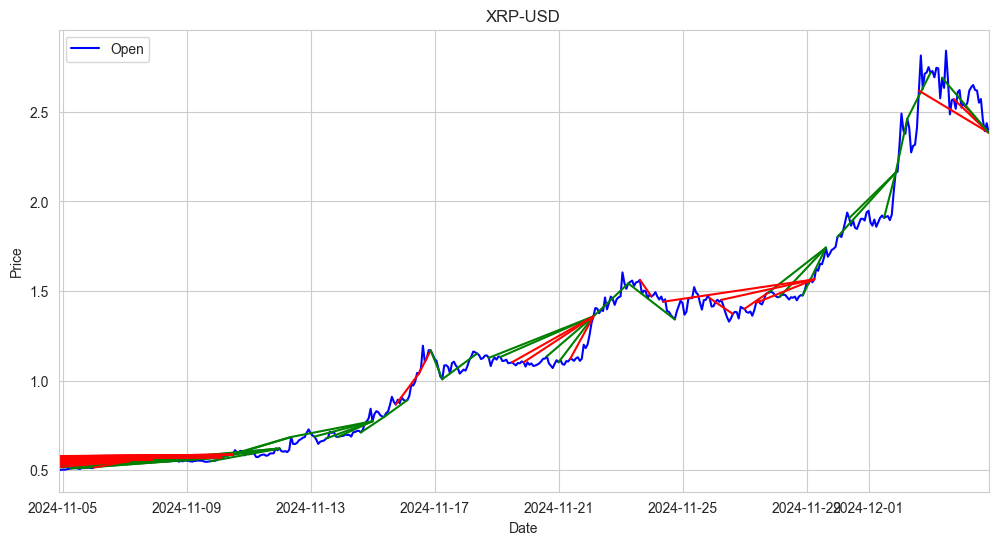

In [ ]:
sns.set_style('whitegrid')

plt.figure(figsize=(12, 6))


plt.plot(btc['Open'], label='Open', color='blue')

# graph the buy positions
""" plt.plot(positions[positions['Type'] == 'buy']['Date Bought'], 
         positions[positions['Type'] == 'buy']['Price Bought'], 
         'o', markersize=5, color='green', label='Buy') """

# starting from price bought draw a line to price sold
for idx, position in positions[positions['Type'] == 'buy'].iterrows():
    if pd.notna(position['Price Sold']):
        color = 'green' if position['Gross Profit'] > 0 else 'red'
        plt.plot([position['Date Bought'], position['Time Sold']], 
                 [position['Price Bought'], position['Price Sold']], 
                 color=color)
        
""" 
# graph the short positions
plt.plot(positions[positions['Type'] == 'short']['Date Bought'], 
         positions[positions['Type'] == 'short']['Price Bought'], 
         'o', markersize=5, color='red', label='Short') """

# starting from price bought draw a line to price sold
for idx, position in positions[positions['Type'] == 'short'].iterrows():
    if pd.notna(position['Price Sold']):
        color = 'green' if position['Gross Profit'] > 0 else 'red'
        plt.plot([position['Date Bought'], position['Time Sold']], 
                 [position['Price Bought'], position['Price Sold']], 
                 color=color)

plt.legend()

plt.title('XRP-USD')
plt.xlabel('Date')
plt.ylabel('Price')

DAYS = 30

plt.xlim(btc.index[-1] - pd.DateOffset(days=DAYS), btc.index[-1])

In [ ]:
# run the model 1000 times and calculate the min, max, average, and std of portfolio value and 